In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from analysis_tools.workflows.evaluation_flow import evaluation_flow
from analysis_tools.workflows.BDT_pipeline import run_bdt_pipeline
from analysis_tools.namings.BDT_feature_naming import BDT_feature_name_change
from analysis_tools.BDT_tools.Testset_preparation import create_learning_input,annotate_labels
from analysis_tools.BDT_tools.BDT_evaluation import find_best_two_bdt_thresholds,plot_bdt_threshold_scan
from analysis_tools.workflows.prediction_flow import prediction_flow,predict_scores
from analysis_tools.my_selectors.apply_selection import apply_selection


/mnt/ceph1-npx/user/zchen/bdt_training/venv/mlvenv_v1/lib/python3.10/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [3]:
model_configs = [
  {
    'name':'bdt1',
    'sig_mask': lambda df: 
                   (df['sig_bdt1']) & 
                   (df['MCTruth_Cascade_Distance_value'] > 10),
    'bg_mask' : 'bg_bdt1'  
  },
  {
    'name':'bdt2',
    'sig_mask': lambda df: 
                   (df['sig_bdt1']) & 
                   (df['MCTruth_Cascade_Distance_value'] > 10),
    'bg_mask' :'bg_bdt2'
  }
]

In [4]:
df_train = pd.read_hdf("/data/user/zchen/data_process/test_sets/Finallevel_nugen_22612-22645.h5")
df_test = pd.read_hdf("/data/user/zchen/data_process/test_sets/Finallevel_nugen_22684-22692.h5")

features_list = ['Taupede_ftpMonoDiff_rlogl_value',
                'Taupede_ftp_Asymmetry_value',
                'Taupede_ftp_Distance_value',
                'Taupede_ftp_1Particles_energy',
                'Taupede_ftp_2Particles_energy',
                'cscdSBU_LE_bdt_input_cscdSBU_MonopodFit4_noDC_zenith',
                'cscdSBU_LE_bdt_input_cscdSBU_MonopodFit4_noDC_Delay_ice_value',
                'CVStatistics_q_max_doms',
                'cscdSBU_LE_bdt_input_cscdSBU_VertexRecoDist_CscdLLh',
                'cscdSBU_MonopodFit4_noDC_energy',
                'cscdSBU_LE_bdt_input_cscdSBU_Qtot_HLC_log_value',]



In [5]:
Taupede_name = 'Taupede_ftp'
precut_dict = {'cscdSBU_MonopodFit4_noDC_energy':('>', 10**4.5),
                  'cscdSBU_Qtot_HLC_value':('>', 10**3),
                  f'{Taupede_name}_Distance_value':[('>', 10),('<', 400)],
                  'cscdSBU_LE_bdt_input_cscdSBU_I3XYScale_noDC_value':('<', 0.9),
                  'cscdSBU_MonopodFit4_noDC_z':{'and':[('>', -500),('<', 500)],
                                                'or':[('>', -50), ('<', -150)]},
                  f'{Taupede_name}_1Particles_x':[('>', -500),('<', 500)],
                  f'{Taupede_name}_1Particles_y':[('>', -500),('<', 500)],
                  f'{Taupede_name}_1Particles_z':{'and':[('>', -500),('<', 500)],
                                                  'or':[('>', -50), ('<', -150)]},
                  f'{Taupede_name}_2Particles_x':[('>', -500),('<', 500)],
                  f'{Taupede_name}_2Particles_y':[('>', -500),('<', 500)],
                  f'{Taupede_name}_2Particles_z':{'and':[('>', -500),('<', 500)],
                                                  'or':[('>', -50), ('<', -150)]},
}

df_train_precut = apply_selection(df_train,precut_dict)
df_test_precut = apply_selection(df_test,precut_dict)

Fitting 5 folds for each of 96 candidates, totalling 480 fits


/mnt/ceph1-npx/user/zchen/bdt_training/venv/mlvenv_v1/lib/python3.10/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/mnt/ceph1-npx/user/zchen/bdt_training/venv/mlvenv_v1/lib/python3.10/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You 

Saved best model to BDT_norlogl_train_22612-22645/train_output/bdt1_model.pkl
Trained bdt1, saved to BDT_norlogl_train_22612-22645/train_output/bdt1_model.pkl


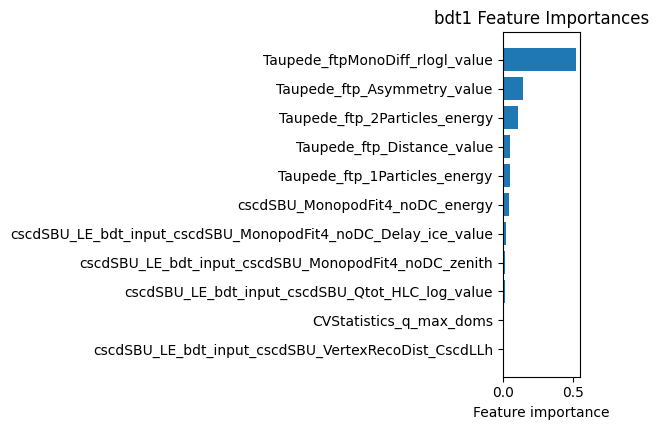

Saved feature importances to BDT_norlogl_train_22612-22645/train_output/bdt1_importances.png
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Saved best model to BDT_norlogl_train_22612-22645/train_output/bdt2_model.pkl
Trained bdt2, saved to BDT_norlogl_train_22612-22645/train_output/bdt2_model.pkl


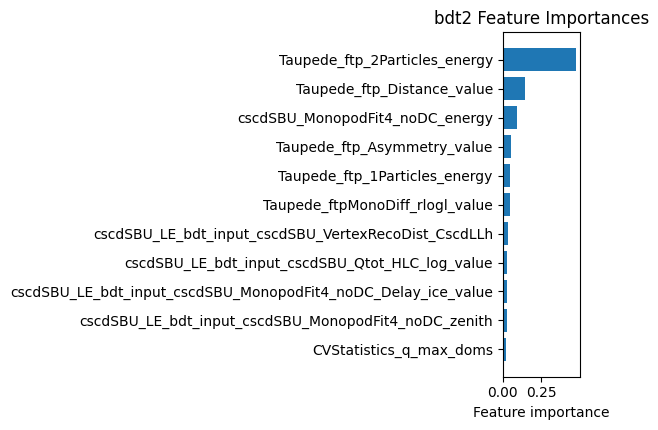

Saved feature importances to BDT_norlogl_train_22612-22645/train_output/bdt2_importances.png

=== Pre-BDT rates ===
Calculating rates for flavor: nue
Raw event count: 38915
[weight] rate        = 2.61134
[weight] uncertainty = 0.0271719
Calculating rates for flavor: numu
Raw event count: 22027
[weight] rate        = 1.76073
[weight] uncertainty = 0.0472809
Calculating rates for flavor: nutau
Raw event count: 43319
[weight] rate        = 1.62911
[weight] uncertainty = 0.0153216


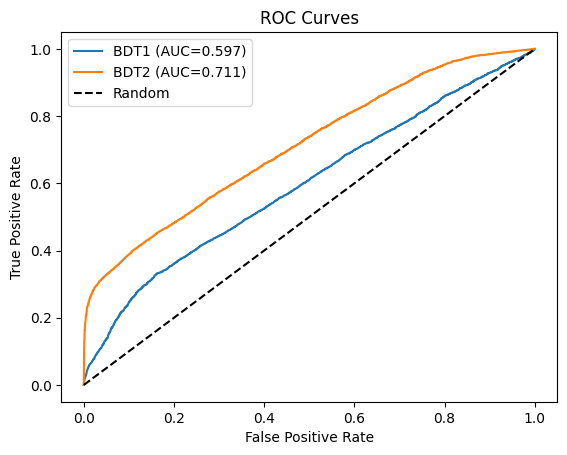

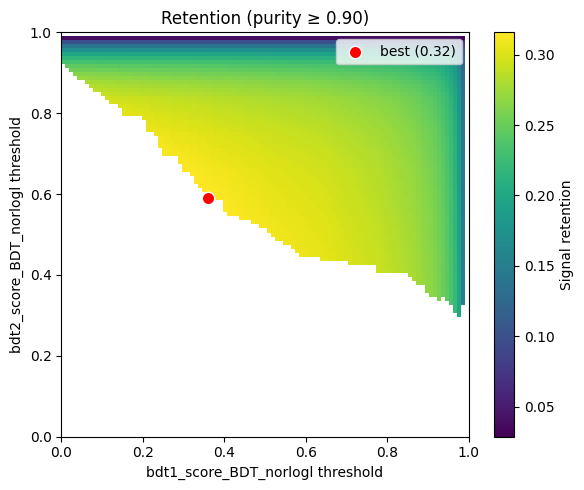


=== Post-BDT rates ===
Calculating post-BDT rates for flavor: nue
Raw event count: 472
[weight] rate        = 0.0166808
[weight] uncertainty = 0.00144888
Calculating post-BDT rates for flavor: numu
Raw event count: 1912
[weight] rate        = 0.0400409
[weight] uncertainty = 0.00438393
Calculating post-BDT rates for flavor: nutau
Raw event count: 22989
[weight] rate        = 0.514513
[weight] uncertainty = 0.00706575


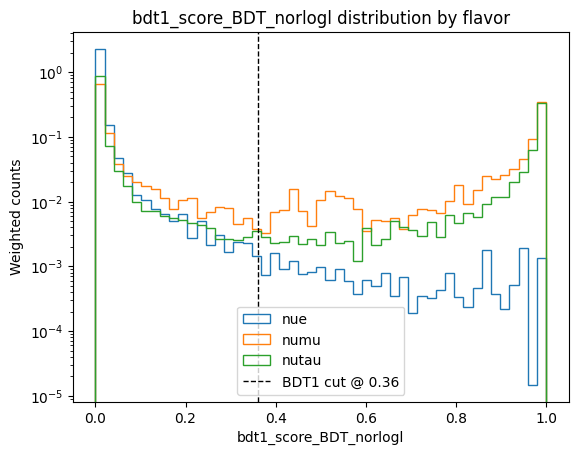

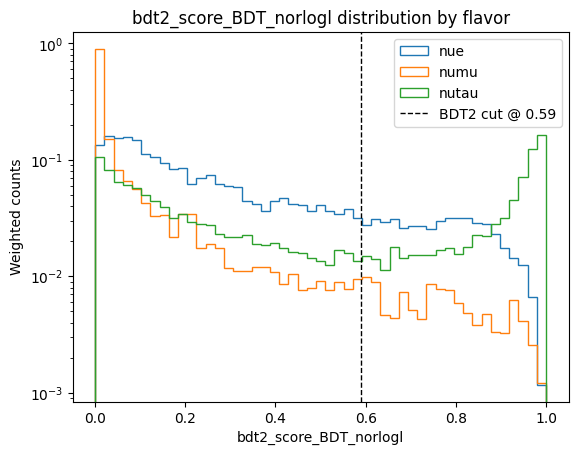

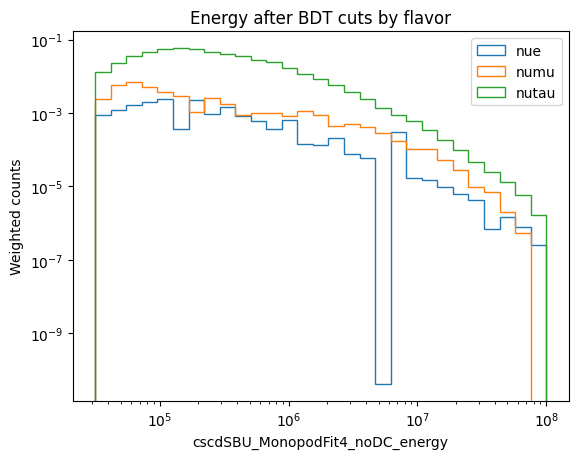


Final purity: 0.901, efficiency: 0.316


In [6]:
model_name = 'BDT_norlogl'

models, summary = run_bdt_pipeline(
    df_train_precut, df_test_precut,
    global_precuts = None,
    model_configs  = model_configs,
    features       = features_list,
    weight_col     = 'weight',
    purity_target  = 0.90,
    score_cols     = [f'bdt1_score_{model_name}',f'bdt2_score_{model_name}'],
    train_outdir   = 'BDT_norlogl_train_22612-22645/train_output/',
    eval_outdir    = 'BDT_norlogl_train_22612-22645/eval_output/'
) 

Fitting 5 folds for each of 96 candidates, totalling 480 fits


/mnt/ceph1-npx/user/zchen/bdt_training/venv/mlvenv_v1/lib/python3.10/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/mnt/ceph1-npx/user/zchen/bdt_training/venv/mlvenv_v1/lib/python3.10/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You 

Saved best model to BDT_norlogl_train_22684-22692/train_output/bdt1_model.pkl
Trained bdt1, saved to BDT_norlogl_train_22684-22692/train_output/bdt1_model.pkl


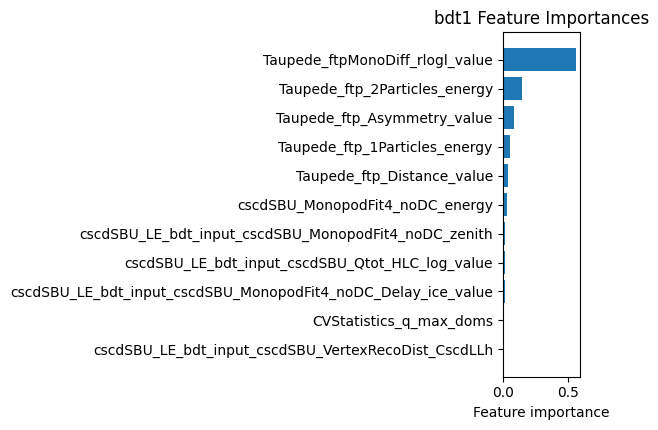

Saved feature importances to BDT_norlogl_train_22684-22692/train_output/bdt1_importances.png
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Saved best model to BDT_norlogl_train_22684-22692/train_output/bdt2_model.pkl
Trained bdt2, saved to BDT_norlogl_train_22684-22692/train_output/bdt2_model.pkl


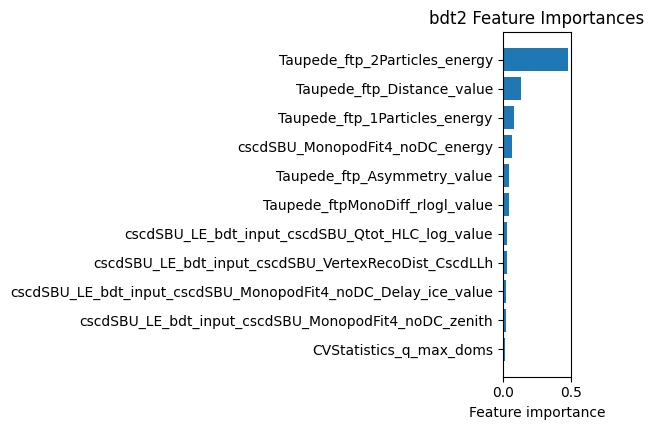

Saved feature importances to BDT_norlogl_train_22684-22692/train_output/bdt2_importances.png

=== Pre-BDT rates ===
Calculating rates for flavor: nue
Raw event count: 28276
[weight] rate        = 1.30843
[weight] uncertainty = 0.0176928
Calculating rates for flavor: numu
Raw event count: 23498
[weight] rate        = 1.70267
[weight] uncertainty = 0.0449605
Calculating rates for flavor: nutau
Raw event count: 39614
[weight] rate        = 1.3329
[weight] uncertainty = 0.013278


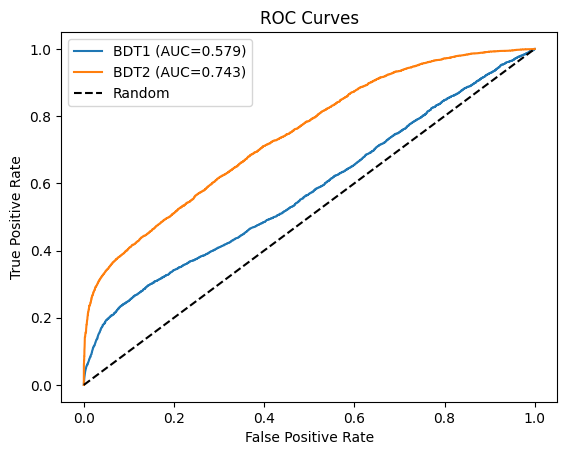

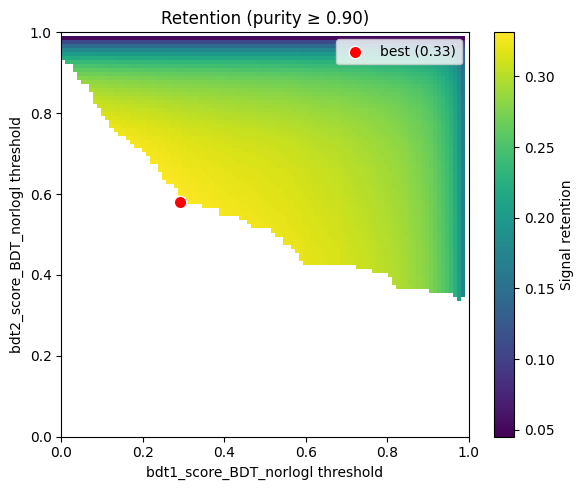


=== Post-BDT rates ===
Calculating post-BDT rates for flavor: nue
Raw event count: 521
[weight] rate        = 0.0150903
[weight] uncertainty = 0.0020165
Calculating post-BDT rates for flavor: numu
Raw event count: 2437
[weight] rate        = 0.0338888
[weight] uncertainty = 0.00334789
Calculating post-BDT rates for flavor: nutau
Raw event count: 21710
[weight] rate        = 0.44133
[weight] uncertainty = 0.00642319


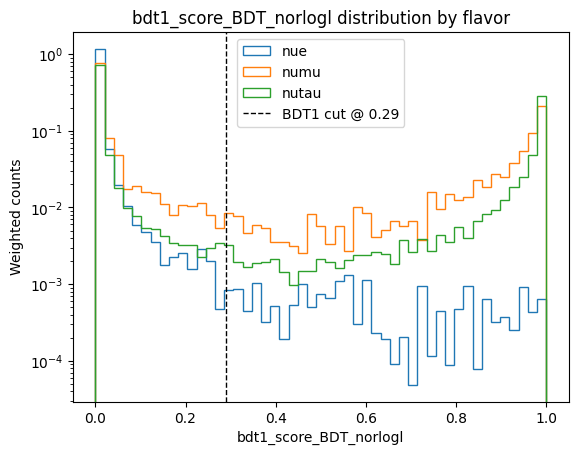

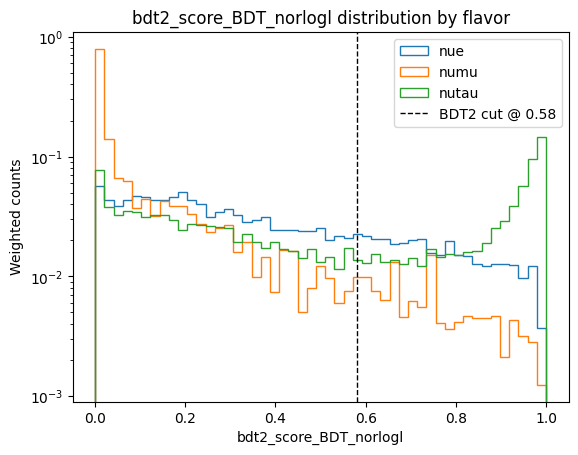

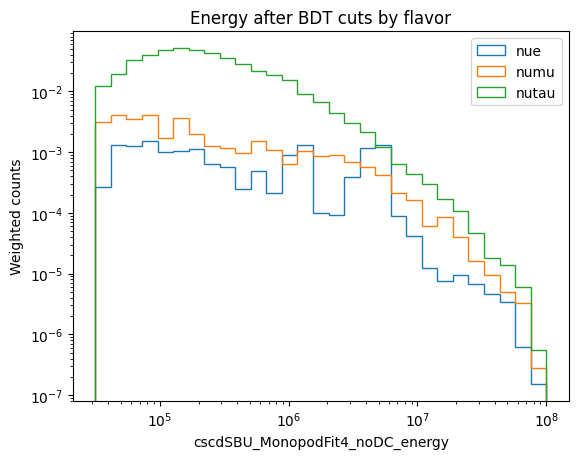


Final purity: 0.900, efficiency: 0.331


In [7]:
model_name = 'BDT_norlogl'

models, summary = run_bdt_pipeline(
    df_test_precut, df_train_precut,
    global_precuts = None,
    model_configs  = model_configs,
    features       = features_list,
    weight_col     = 'weight',
    purity_target  = 0.90,
    score_cols     = [f'bdt1_score_{model_name}',f'bdt2_score_{model_name}'],
    train_outdir   = 'BDT_norlogl_train_22684-22692/train_output/',
    eval_outdir    = 'BDT_norlogl_train_22684-22692/eval_output/'
) 